In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

In [2]:
merged = pd.read_csv("../data/merged.csv")
print(merged.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures_mat', 'schoolsup', 'famsup', 'paid_mat', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences_mat', 'G1_mat', 'G2_mat',
       'G3_mat', 'failures_por', 'paid_por', 'absences_por', 'G1_por',
       'G2_por', 'G3_por', 'reussite_mat', 'reussite_por', 'reussite'],
      dtype='object')


In [3]:
# prep

num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
 
# l'élève/études supérieures ?
merged_model = merged[num_cols + ['higher']].dropna()
X_raw = merged_model[num_cols].values
y = (merged_model['higher'] == 'yes').astype(int).values
 
# Normalisation 
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
 
print(f"{X.shape[0]} individus | classes : {np.bincount(y)} (0=non, 1=oui)")

674 individus | classes : [ 73 601] (0=non, 1=oui)


Evaluation du modèle
Précision globale (Accuracy) : 87.41%

Rapport de classification :
              precision    recall  f1-score   support

     Non (0)       0.00      0.00      0.00        15
     Oui (1)       0.89      0.98      0.93       120

    accuracy                           0.87       135
   macro avg       0.44      0.49      0.47       135
weighted avg       0.79      0.87      0.83       135



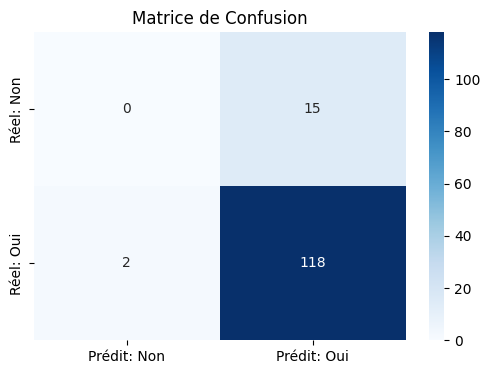

In [4]:
# Séparation des données (80% entraînement, 20% test)
# On utilise stratify=y pour conserver la même proportion de 0 et de 1 dans les deux échantillons
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Evaluation du modèle")
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision globale (Accuracy) : {accuracy:.2%}\n")

print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=["Non (0)", "Oui (1)"]))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Prédit: Non", "Prédit: Oui"], 
            yticklabels=["Réel: Non", "Réel: Oui"])
plt.title('Matrice de Confusion')
plt.show()

In [5]:
# Afficher l'importance des variables
import pandas as pd
importance = pd.DataFrame({'Variable': num_cols, 'Coefficient': model.coef_[0]})
print(importance.sort_values(by='Coefficient', ascending=False))

      Variable  Coefficient
4    studytime     0.797175
2         Fedu     0.445624
1         Medu     0.307503
5       famrel     0.147249
10      health     0.115968
7        goout     0.027551
9         Walc     0.020117
8         Dalc    -0.077154
3   traveltime    -0.120497
6     freetime    -0.315134
0          age    -0.827893
